In [1]:
channel_name = 'lexfridman'

In [3]:
import pandas as pd
from datetime import datetime, timedelta
from googleapiclient.discovery import build
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
# Load environment variables from .env file
load_dotenv()

# Retrieve API key from environment variables
YOUTUBE_DEVELOPER_KEY = os.getenv('YOUTUBE_DEVELOPER_KEY')

# Verify API key is loaded
if not YOUTUBE_DEVELOPER_KEY:
    raise ValueError("YouTube API key not found. Please create a .env file with YOUTUBE_API_KEY=")
    
youtube = build('youtube', 'v3', developerKey=YOUTUBE_DEVELOPER_KEY)

In [5]:
def get_quota_reset_info():
    """Get information about when quota resets and suggest action"""
    from datetime import datetime, timezone, timedelta
    import pytz
    
    pacific = pytz.timezone('America/Los_Angeles')
    now_pt = datetime.now(pacific)
    
    # Calculate next reset time (midnight PT)
    reset_time = now_pt.replace(hour=0, minute=0, second=0, microsecond=0)
    if now_pt >= reset_time:
        reset_time += timedelta(days=1)
    
    time_until_reset = reset_time - now_pt
    hours_until_reset = time_until_reset.total_seconds() / 3600
    
    print(f"Current PT time: {now_pt.strftime('%H:%M')}")
    print(f"Quota resets in: {hours_until_reset:.1f} hours")
    
    if hours_until_reset < 4:
        print("⚠️  Caution: Limited time until quota reset")
        if hours_until_reset < 1:
            print("✅ Consider waiting for fresh quota")
    
    return hours_until_reset

# Use it like this:
if get_quota_reset_info() < 2:
    # Very little time until reset
    print("You might want to wait for quota reset")

Current PT time: 00:18
Quota resets in: 23.7 hours


In [7]:
def get_channel(channel_name):
    return youtube.search().list(q=channel_name, type='channel', part='id,snippet').execute()['items'][0]

In [9]:
channel_id = get_channel(channel_name)['id']['channelId']
channel_id

'UCSHZKyawb77ixDdsGog4iWA'

# Diving into YouTube Analytics
Deepnote presented a live stream featuring a showcase of how to use Google's YouTube API. We had a few Deepnote coders and a Deepnote user Allan who helped crack the API and start getting data. Below is a project inspired from that stream!

In this notebook we are going to dive in and check out the popular YouTube channel Good Mythical Morning.

## API Functions
In this section we setup some API functions to help us gather data. We create a function to gather channel stats and video stats. To do this in a effecient way and save API calls we do not use the search function. We pull in GMM's upload playlist ( containing all of their videos ) and use that to build a video list. Then grab the data from each video.

In [13]:
# Function to get the channels stats
# It will also contain the upload playlist ID we can use to grab videos.
def get_channel_stats(youtube, channel_id):
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    response = request.execute()
    
    return response['items']

In [15]:
# This will get us a list of videos from a playlist.
# Note a page of results has a max value of 50 so we will
# need to loop over our results with a pageToken

def get_video_list(youtube, upload_id):
    video_list = []
    request = youtube.playlistItems().list(
        part="snippet,contentDetails",
        playlistId=upload_id,
        maxResults=50
    )
    next_page = True
    while next_page:
        response = request.execute()
        data = response['items']

        for video in data:
            video_id = video['contentDetails']['videoId']
            if video_id not in video_list:
                video_list.append(video_id)

        # Do we have more pages?
        if 'nextPageToken' in response.keys():
            next_page = True
            request = youtube.playlistItems().list(
                part="snippet,contentDetails",
                playlistId=upload_id,
                pageToken=response['nextPageToken'],
                maxResults=50
            )
        else:
            next_page = False

    return video_list

In [17]:
# new function
def get_video_details(youtube, video_list):
    stats_list = []

    # Can only get 50 videos at a time.
    for i in range(0, len(video_list), 50):
        request = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=video_list[i:i+50]
        )

        data = request.execute()
        for video in data['items']:
            video_id = video['id']  # Extract video_id 
            title = video['snippet']['title']
            published = video['snippet']['publishedAt']
            description = video['snippet']['description']
            view_count = video['statistics'].get('viewCount', 0)
            like_count = video['statistics'].get('likeCount', 0)
            dislike_count = video['statistics'].get('dislikeCount', 0)
            comment_count = video['statistics'].get('commentCount', 0)
            duration = video['contentDetails'].get('duration', 'Unknown')  # Use .get() with a default value

            # Include video_id in the dictionary
            stats_dict = dict(
                video_id=video_id,
                title=title,
                description=description,
                published=published,
                view_count=view_count,
                like_count=like_count,
                dislike_count=dislike_count,
                comment_count=comment_count,
                duration=duration             
            )
            stats_list.append(stats_dict)

    return stats_list

In [19]:
def convert_iso_duration_to_hms(duration):
    """
    Converts an ISO 8601 duration string (e.g., 'PT3M54S') to 'H:M:S' format.
    
    Args:
        duration (str): The ISO 8601 duration string (e.g., 'PT3M54S').
    
    Returns:
        str: The duration in 'H:M:S' format.
    """
    # Regex to extract hours, minutes, and seconds from the ISO 8601 duration
    pattern = re.compile(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?')
    match = pattern.match(duration)
    
    if not match:
        return "0:00:00"  # Default if the format is invalid
    
    # Extract hours, minutes, and seconds
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    
    # Create a timedelta object
    delta = timedelta(hours=hours, minutes=minutes, seconds=seconds)
    
    # Convert to total seconds
    total_seconds = int(delta.total_seconds())
    
    # Convert total seconds to H:M:S format
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    
    return f"{hours}:{minutes:02d}:{seconds:02d}"

## Create our Channel Stats

In [22]:
channel_stats = get_channel_stats(youtube, channel_id)

## Find our Upload Playlist ( will contain all video uploads )

In [25]:
upload_id = channel_stats[0]['contentDetails']['relatedPlaylists']['uploads']
upload_id

'UUSHZKyawb77ixDdsGog4iWA'

## Get our Video List

In [28]:
video_list = get_video_list(youtube, upload_id)

## Get our Video Details
## Finally we will get all of our videos details returned in a dictionary.

In [31]:
video_data = get_video_details(youtube, video_list)
'Number 0f Videos: ' + str(len(video_data))

'Number 0f Videos: 868'

## Pause and think what to do next

In [34]:
df=pd.DataFrame(video_data)
df.shape

(868, 9)

In [36]:
df['title_length'] = df['title'].str.len()
df["view_count"] = pd.to_numeric(df["view_count"])
df["like_count"] = pd.to_numeric(df["like_count"])
df["dislike_count"] = pd.to_numeric(df["dislike_count"])
df["comment_count"] = pd.to_numeric(df["comment_count"])
df["published"] = pd.to_datetime(df["published"])
# Format the 'published' column to "%Y-%m-%d"
df["published"] = df["published"].dt.strftime("%Y-%m-%d")
# reaction used later add up likes + dislikes + comments
df["reactions"] = df["like_count"] + df["dislike_count"] + df["comment_count"] + df["comment_count"]
df['hms_format'] = df['duration'].apply(convert_iso_duration_to_hms)

In [46]:
# Select rows where the title contains "Animation Maker"
result = df
#result = df.query('title.str.upper().str.contains("DHH")', engine='python')
result.shape

(868, 12)

In [48]:
cols = 'video_id title published view_count title_length hms_format'.split()

In [50]:
# Retrieve the maximum value from the title_length column
max_title_length = result['title_length'].max()
print("Maximum title length:", max_title_length)
# Set pandas column display width to the maximum title_length value
pd.set_option('display.max_colwidth', max_title_length)
result[cols].sort_values(by='published', ascending=False).head(30)

Maximum title length: 100


,video_id,title,published,view_count,title_length,hms_format
0,s7d2d8FhevU,"Psychiatry, Insane Asylums, Mental Illness, ECT, Lobotomies, Freud & Jung | Lex Fridman Podcast ...",2026-09-17,596797,100,3:36:56
1,NYFGCESmikA,"DHH: Future of Programming, AI, Agentic Engineering, Vibe Coding & Linux | Lex Fridman Podcast #501",2026-08-26,1875035,99,5:15:51
2,l6USUAIKJls,"Khabib Nurmagomedov: Dagestan, MMA, UFC, Islam, Conor, Fedor & Football | Lex Fridman Podcast #500",2026-08-12,2042036,98,3:12:58
3,XyXBwO5jYpw,"Gary Gallagher: American Civil War, Slavery, Lincoln, Grant & Lee | Lex Fridman Podcast #499",2026-07-28,974067,92,3:46:18
4,pv1TUJSEM2k,The Rise and Fall of the Roman Empire and the Byzantine Empire | Lex Fridman Podcast #498,2026-06-30,1146638,89,3:51:47
5,1M3Vdl6DRkU,"Biggest Mysteries in Physics: Antimatter, Dark Energy & ToE - Don Lincoln | Lex Fridman Podcast ...",2026-05-29,817439,100,2:53:43
6,nepKKz-MzFM,FFmpeg: The Incredible Technology Behind Video on the Internet | Lex Fridman Podcast #496,2026-05-06,351912,89,4:18:22
7,iKx3gAODybU,"Vikings, Ragnar, Berserkers, Valhalla & the Warriors of the Viking Age | Lex Fridman Podcast #495",2026-04-09,1350689,97,2:03:24
8,vif8NQcjVf0,Jensen Huang: NVIDIA - The $4 Trillion Company & the AI Revolution | Lex Fridman Podcast #494,2026-03-23,1366894,93,2:25:59
9,H9rF1CSSh-w,"Jeff Kaplan: World of Warcraft, Overwatch, Blizzard, and Future of Gaming | Lex Fridman Podcast ...",2026-03-11,942368,100,5:10:12


## Most Viewed Videos

In [53]:
df_highest_views = result.nlargest(10, 'view_count')
df_highest_views['title'] = df_highest_views['title'].str[:94]
df_highest_views['view_count_millions'] = df_highest_views['view_count'] / 1000
df_highest_views[cols]

,video_id,title,published,view_count,title_length,hms_format
211,T3FC7qIAGZk,Andrew Bustamante: CIA Spy | Lex Fridman Podcast #310,2022-08-08,19965212,53,3:53:09
101,f_lRdkH_QoY,"Tucker Carlson: Putin, Navalny, Trump, CIA, NSA, War, Politics & Freedom | Lex Fridman Podcast",2024-02-27,16978483,99,3:04:22
208,sY8aFSY2zv4,"Jordan Peterson: Life, Death, Power, Fame, and Meaning | Lex Fridman Podcast #313",2022-08-19,16800436,81,3:03:33
115,JN3KPFbWCy8,"Elon Musk: War, AI, Aliens, Politics, Physics, Video Games, and Humanity | Lex Fridman Podcast",2023-11-09,14291340,99,2:16:47
149,gPfriiHBBek,"Paul Rosolie: Amazon Jungle, Uncontacted Tribes, Anacondas, and Ayahuasca | Lex Fridman Podcas",2023-04-04,13022498,100,3:34:58
163,uZN5xjoS6TU,David Kipping: Alien Civilizations and Habitable Worlds | Lex Fridman Podcast #355,2023-01-28,12478765,82,3:47:10
105,tYrdMjVXyNg,"Ben Shapiro vs Destiny Debate: Politics, Jan 6, Israel, Ukraine & Wokeism | Lex Fridman Podcas",2024-01-23,12452492,100,2:20:05
248,mC43pZkpTec,"Michael Saylor: Bitcoin, Inflation, and the Future of Money | Lex Fridman Podcast #276",2022-04-14,11427934,86,3:56:55
278,DxREm3s1scA,"Elon Musk: SpaceX, Mars, Tesla Autopilot, Self-Driving, Robotics, and AI | Lex Fridman Podcast",2021-12-28,11174383,99,2:31:48
222,gk4tEO4jDUM,"Joe Rogan: Comedy, Controversy, Aliens, UFOs, Putin, CIA, and Freedom | Lex Fridman Podcast #3",2022-07-04,10831695,96,1:41:21


In [55]:
df_highest_views[cols].sort_values(by="published",ascending=False)

,video_id,title,published,view_count,title_length,hms_format
101,f_lRdkH_QoY,"Tucker Carlson: Putin, Navalny, Trump, CIA, NSA, War, Politics & Freedom | Lex Fridman Podcast",2024-02-27,16978483,99,3:04:22
105,tYrdMjVXyNg,"Ben Shapiro vs Destiny Debate: Politics, Jan 6, Israel, Ukraine & Wokeism | Lex Fridman Podcas",2024-01-23,12452492,100,2:20:05
115,JN3KPFbWCy8,"Elon Musk: War, AI, Aliens, Politics, Physics, Video Games, and Humanity | Lex Fridman Podcast",2023-11-09,14291340,99,2:16:47
149,gPfriiHBBek,"Paul Rosolie: Amazon Jungle, Uncontacted Tribes, Anacondas, and Ayahuasca | Lex Fridman Podcas",2023-04-04,13022498,100,3:34:58
163,uZN5xjoS6TU,David Kipping: Alien Civilizations and Habitable Worlds | Lex Fridman Podcast #355,2023-01-28,12478765,82,3:47:10
208,sY8aFSY2zv4,"Jordan Peterson: Life, Death, Power, Fame, and Meaning | Lex Fridman Podcast #313",2022-08-19,16800436,81,3:03:33
211,T3FC7qIAGZk,Andrew Bustamante: CIA Spy | Lex Fridman Podcast #310,2022-08-08,19965212,53,3:53:09
222,gk4tEO4jDUM,"Joe Rogan: Comedy, Controversy, Aliens, UFOs, Putin, CIA, and Freedom | Lex Fridman Podcast #3",2022-07-04,10831695,96,1:41:21
248,mC43pZkpTec,"Michael Saylor: Bitcoin, Inflation, and the Future of Money | Lex Fridman Podcast #276",2022-04-14,11427934,86,3:56:55
278,DxREm3s1scA,"Elon Musk: SpaceX, Mars, Tesla Autopilot, Self-Driving, Robotics, and AI | Lex Fridman Podcast",2021-12-28,11174383,99,2:31:48


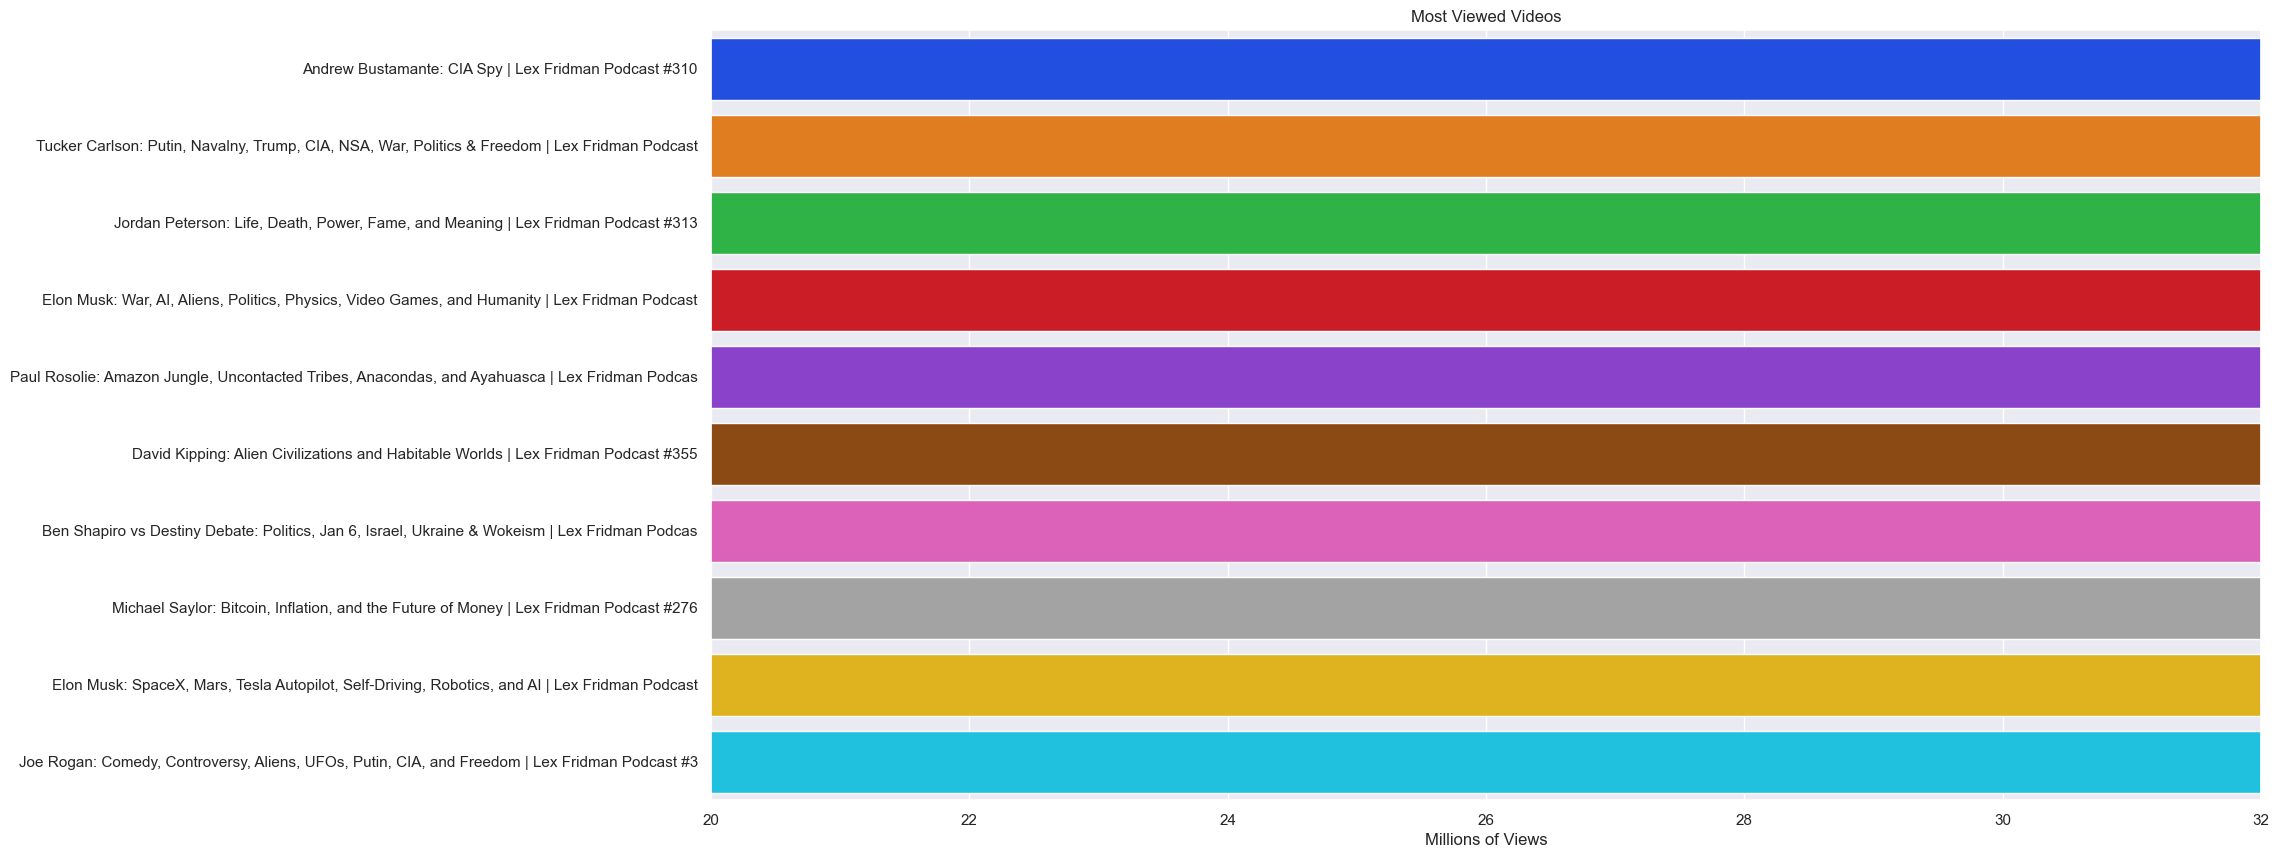

In [57]:
# Set the figure size
sns.set(rc={'figure.figsize': (20, 10)})

# Create the barplot
plot = sns.barplot(
    x="view_count_millions", 
    y="title", 
    hue="title",  # Assign y variable to hue
    data=df_highest_views, 
    palette="bright", 
    legend=False  # Disable the legend
)

# Set labels and title
plot.set(xlabel='Millions of Views', ylabel='')
plot.set_title('Most Viewed Videos')

# Set x-axis limits
plt.xlim(20, 32)

# Show the plot
plt.show()

In [59]:
colt = 'video_id title published view_count hms_format'.split()
output_file = channel_name + '.csv'
result[colt].to_csv(output_file, index=None)
result[colt].sort_values(by="published",ascending=False)

,video_id,title,published,view_count,hms_format
0,s7d2d8FhevU,"Psychiatry, Insane Asylums, Mental Illness, ECT, Lobotomies, Freud & Jung | Lex Fridman Podcast ...",2026-09-17,596797,3:36:56
1,NYFGCESmikA,"DHH: Future of Programming, AI, Agentic Engineering, Vibe Coding & Linux | Lex Fridman Podcast #501",2026-08-26,1875035,5:15:51
2,l6USUAIKJls,"Khabib Nurmagomedov: Dagestan, MMA, UFC, Islam, Conor, Fedor & Football | Lex Fridman Podcast #500",2026-08-12,2042036,3:12:58
3,XyXBwO5jYpw,"Gary Gallagher: American Civil War, Slavery, Lincoln, Grant & Lee | Lex Fridman Podcast #499",2026-07-28,974067,3:46:18
4,pv1TUJSEM2k,The Rise and Fall of the Roman Empire and the Byzantine Empire | Lex Fridman Podcast #498,2026-06-30,1146638,3:51:47
...,...,...,...,...,...
863,7bO8rKtvDoE,Jimmy Pedro: Judo | Take It Uneasy Podcast,2014-12-23,53744,1:00:13
864,7XzAsx-aRC4,Ryan Hall: Principles of Jiu Jitsu | Take It Uneasy Podcast,2014-06-16,182471,0:09:48
865,HGZ4E-qUd1A,Ryan Hall: Best Martial Art for Self Defense | Take It Uneasy Podcast,2014-06-11,476343,0:04:37
866,qySBeiY8EqA,Ryan Hall: Moral Victory,2014-06-05,38664,0:03:22


In [42]:
# Get the user's home directory
user_path = os.path.expanduser('~')
# Get the current working directory
current_path = os.getcwd()
# Derive the base directory (base_dir) by removing the last folder ('Daily')
base_path = os.path.dirname(current_path)
#C:\Users\PC1\OneDrive\A5\Excel
xsl_path = os.path.join(base_path, "Excel")

In [44]:
print("User path:", user_path)
print(f"Current path: {current_path}")
print(f"Base path: {base_path}")
print(f"Excel path (xsl_path): {xsl_path}")

User path: C:\Users\PC1
Current path: C:\Users\PC1\OneDrive\A4\YouTube
Base path: C:\Users\PC1\OneDrive\A4
Excel path (xsl_path): C:\Users\PC1\OneDrive\A4\Excel


In [46]:
xsl_file = channel_name + '.xlsx'
xsl_file = os.path.join(xsl_path, xsl_file)
xsl_file

'C:\\Users\\PC1\\OneDrive\\A4\\Excel\\AiSeeKing.xlsx'

In [48]:
colt = 'video_id title published view_count hms_format read'.split()
df_highest_views['read'] = 'N'
df_highest_views[colt].to_excel(xsl_file, index=False)